# Image Classification EDA — Pixel-Level Stats

Set `FOLDER` below to your image directory, then run all cells.

In [7]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp", ".tiff", ".tif"}

# EDIT THIS to point to your image folder
FOLDER = "/home/hoangLD/Desktop/AIVIETNAM/Module-01/AIO-CONQUER/image-preprocessing-classification/data/raw/India/train/images"

# Optional: cap number of images for a quick pass on huge datasets (None = use all)
MAX_IMAGES = None


## 1. Collect image data (dimensions, file size, per-channel mean/std, brightness, contrast)

In [8]:
def collect_image_data(folder, max_images=None):
    data = []
    for root, _, files in os.walk(folder):
        for fname in files:
            ext = os.path.splitext(fname)[1].lower()
            if ext not in IMAGE_EXTS:
                continue
            fpath = os.path.join(root, fname)
            try:
                with Image.open(fpath) as img:
                    img_rgb = img.convert("RGB")  # force 3-channel for consistency
                    width, height = img_rgb.size
                    arr = np.asarray(img_rgb, dtype=np.float32)  # H x W x 3, values 0-255

                    mean_r, mean_g, mean_b = arr[:, :, 0].mean(), arr[:, :, 1].mean(), arr[:, :, 2].mean()
                    std_r, std_g, std_b = arr[:, :, 0].std(), arr[:, :, 1].std(), arr[:, :, 2].std()

                    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
                    brightness = gray.mean()
                    contrast = gray.std()

                file_size_kb = os.path.getsize(fpath) / 1024
                data.append({
                    "name": fname,
                    "path": fpath,
                    "width": width,
                    "height": height,
                    "size_kb": file_size_kb,
                    "mean_r": mean_r, "mean_g": mean_g, "mean_b": mean_b,
                    "std_r": std_r, "std_g": std_g, "std_b": std_b,
                    "brightness": brightness,
                    "contrast": contrast,
                })

                if max_images and len(data) >= max_images:
                    return data

            except Exception as e:
                print(f"Skipping {fpath}: {e}")

    return data


image_data = collect_image_data(FOLDER, max_images=MAX_IMAGES)
print(f"Collected data for {len(image_data)} images.")


Collected data for 7706 images.


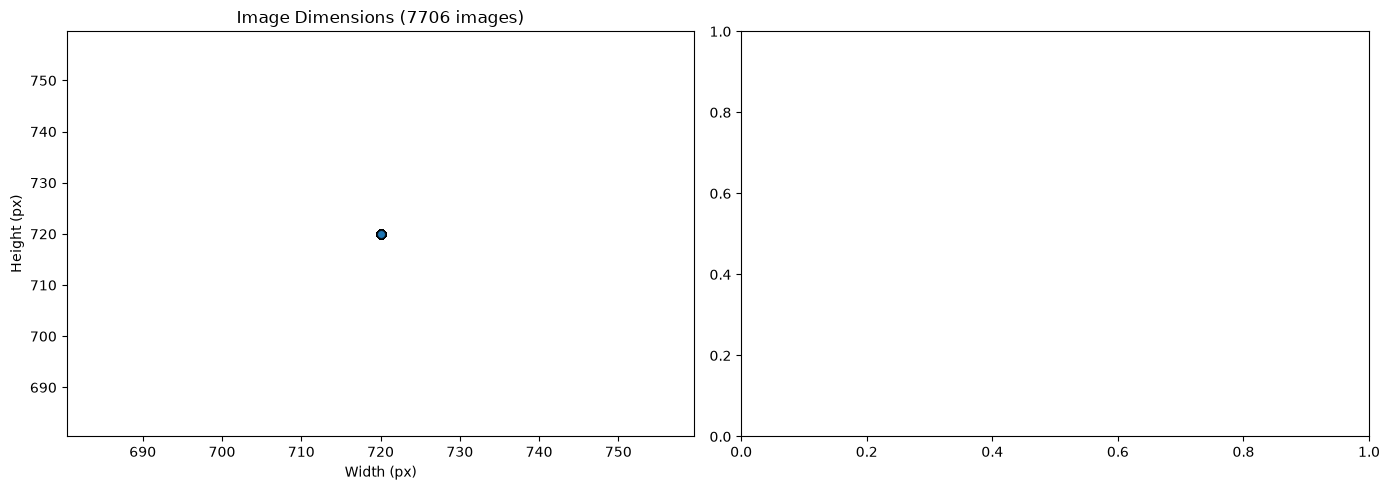

--- Dimension / size summary ---
Width  - min: 720, max: 720, avg: 720.0
Height - min: 720, max: 720, avg: 720.0
File size (KB) - min: 18.1, max: 135.3, avg: 65.9

Number of distinct (width, height) combinations: 1
Most common dimensions:
  720x720: 7706 images

Very small images (<32px on a side): 0
Very large images (>4000px on a side): 0


In [ ]:
widths = [d["width"] for d in image_data]
heights = [d["height"] for d in image_data]
sizes_kb = [d["size_kb"] for d in image_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width vs Height scatter
axes[0].scatter(widths, heights, alpha=0.6, edgecolors="k")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title(f"Image Dimensions ({len(image_data)} images)")
#axes[0].grid(True, linestyle="--", alpha=0.5)

# File size histogram
#axes[1].hist(sizes_kb, bins=30, color="steelblue", edgecolor="black")
#axes[1].set_xlabel("File Size (KB)")
#axes[1].set_ylabel("Number of images")
#axes[1].set_title("Image File Size Distribution")
#axes[1].grid(True, linestyle="--", alpha=0.5)

#plt.tight_layout()
plt.show()

print("--- Dimension / size summary ---")
print(f"Width  - min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.1f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.1f}")
print(f"File size (KB) - min: {min(sizes_kb):.1f}, max: {max(sizes_kb):.1f}, avg: {sum(sizes_kb)/len(sizes_kb):.1f}")

# Flag images with unique / inconsistent dimensions
from collections import Counter
dim_counts = Counter((d["width"], d["height"]) for d in image_data)
print(f"\nNumber of distinct (width, height) combinations: {len(dim_counts)}")
print("Most common dimensions:")
for dim, count in dim_counts.most_common(5):
    print(f"  {dim[0]}x{dim[1]}: {count} images")

# Flag very small or very large images (possible corrupt/thumbnail/outlier files)
tiny = [d["name"] for d in image_data if d["width"] < 32 or d["height"] < 32]
huge = [d["name"] for d in image_data if d["width"] > 4000 or d["height"] > 4000]
print(f"\nVery small images (<32px on a side): {len(tiny)}")
print(f"Very large images (>4000px on a side): {len(huge)}")

## 2. Per-channel mean/std of pixel values (also gives normalization values)

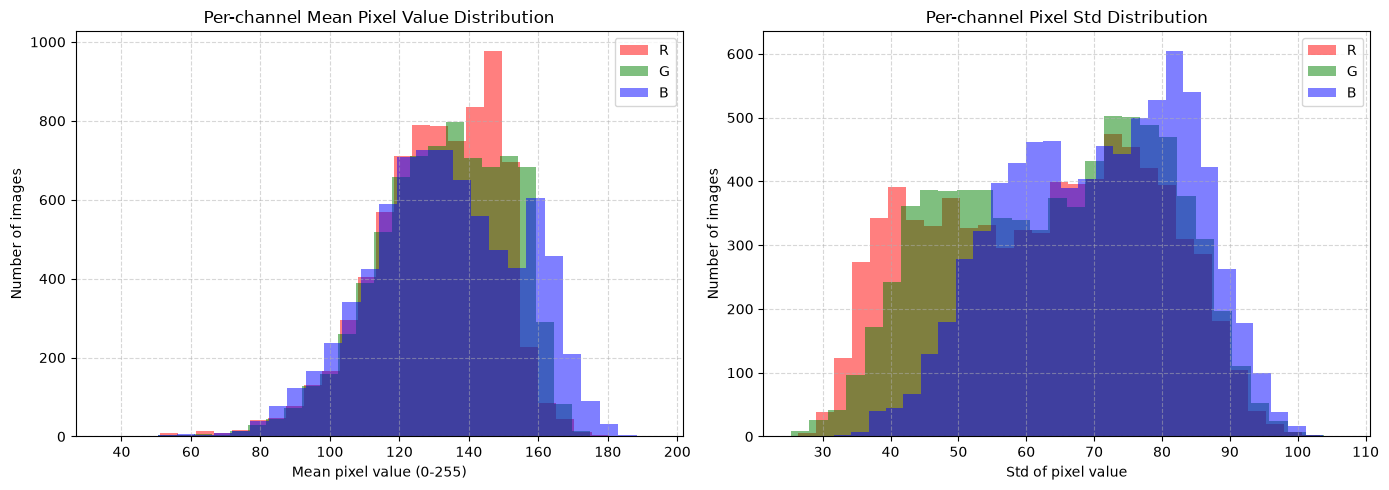

--- Suggested normalization values (dataset-wide, 0-1 scale) ---
mean = [0.5126, 0.5209, 0.5222]
std  = [0.2444, 0.2529, 0.2769]


In [9]:
mean_r = [d["mean_r"] for d in image_data]
mean_g = [d["mean_g"] for d in image_data]
mean_b = [d["mean_b"] for d in image_data]
std_r = [d["std_r"] for d in image_data]
std_g = [d["std_g"] for d in image_data]
std_b = [d["std_b"] for d in image_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mean_r, bins=30, alpha=0.5, label="R", color="red")
axes[0].hist(mean_g, bins=30, alpha=0.5, label="G", color="green")
axes[0].hist(mean_b, bins=30, alpha=0.5, label="B", color="blue")
axes[0].set_xlabel("Mean pixel value (0-255)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Per-channel Mean Pixel Value Distribution")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(std_r, bins=30, alpha=0.5, label="R", color="red")
axes[1].hist(std_g, bins=30, alpha=0.5, label="G", color="green")
axes[1].hist(std_b, bins=30, alpha=0.5, label="B", color="blue")
axes[1].set_xlabel("Std of pixel value")
axes[1].set_ylabel("Number of images")
axes[1].set_title("Per-channel Pixel Std Distribution")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("--- Suggested normalization values (dataset-wide, 0-1 scale) ---")
print(f"mean = [{np.mean(mean_r)/255:.4f}, {np.mean(mean_g)/255:.4f}, {np.mean(mean_b)/255:.4f}]")
print(f"std  = [{np.mean(std_r)/255:.4f}, {np.mean(std_g)/255:.4f}, {np.mean(std_b)/255:.4f}]")


## 3. Brightness / contrast distribution (flags over/under-exposed images)

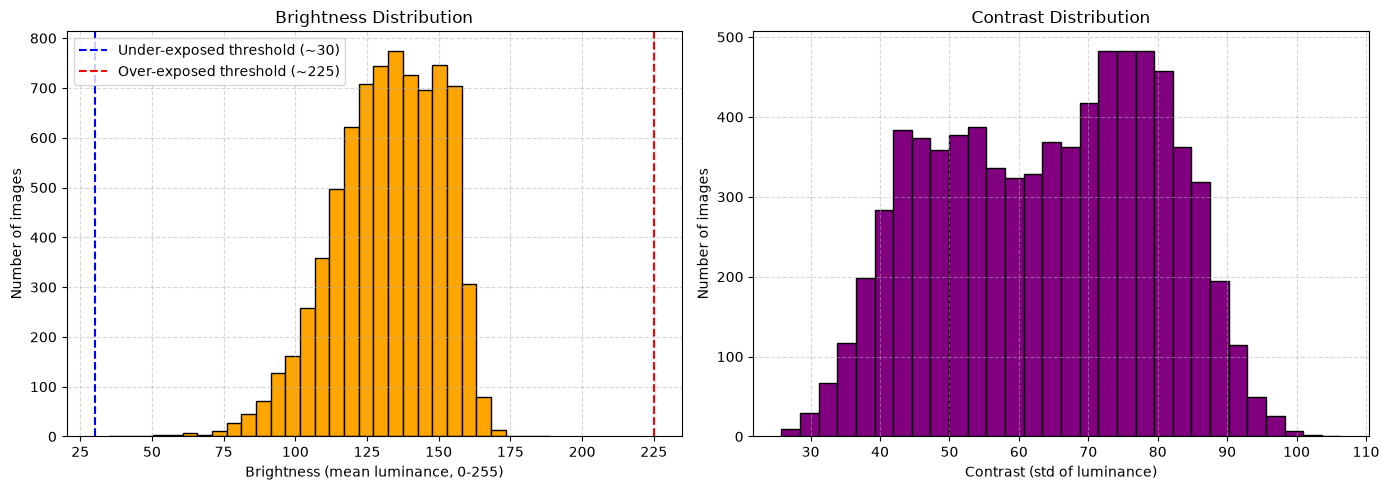

Possibly under-exposed images (brightness < 30): 0
Possibly over-exposed images (brightness > 225): 0
Possibly low-contrast / flat images (std < 15): 0


In [10]:
brightness = [d["brightness"] for d in image_data]
contrast = [d["contrast"] for d in image_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(brightness, bins=30, color="orange", edgecolor="black")
axes[0].axvline(30, color="blue", linestyle="--", label="Under-exposed threshold (~30)")
axes[0].axvline(225, color="red", linestyle="--", label="Over-exposed threshold (~225)")
axes[0].set_xlabel("Brightness (mean luminance, 0-255)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Brightness Distribution")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(contrast, bins=30, color="purple", edgecolor="black")
axes[1].set_xlabel("Contrast (std of luminance)")
axes[1].set_ylabel("Number of images")
axes[1].set_title("Contrast Distribution")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

dark = [d["name"] for d in image_data if d["brightness"] < 30]
bright = [d["name"] for d in image_data if d["brightness"] > 225]
low_contrast = [d["name"] for d in image_data if d["contrast"] < 15]

print(f"Possibly under-exposed images (brightness < 30): {len(dark)}")
print(f"Possibly over-exposed images (brightness > 225): {len(bright)}")
print(f"Possibly low-contrast / flat images (std < 15): {len(low_contrast)}")


## 4. Aggregate pixel intensity histogram (sampled for speed)

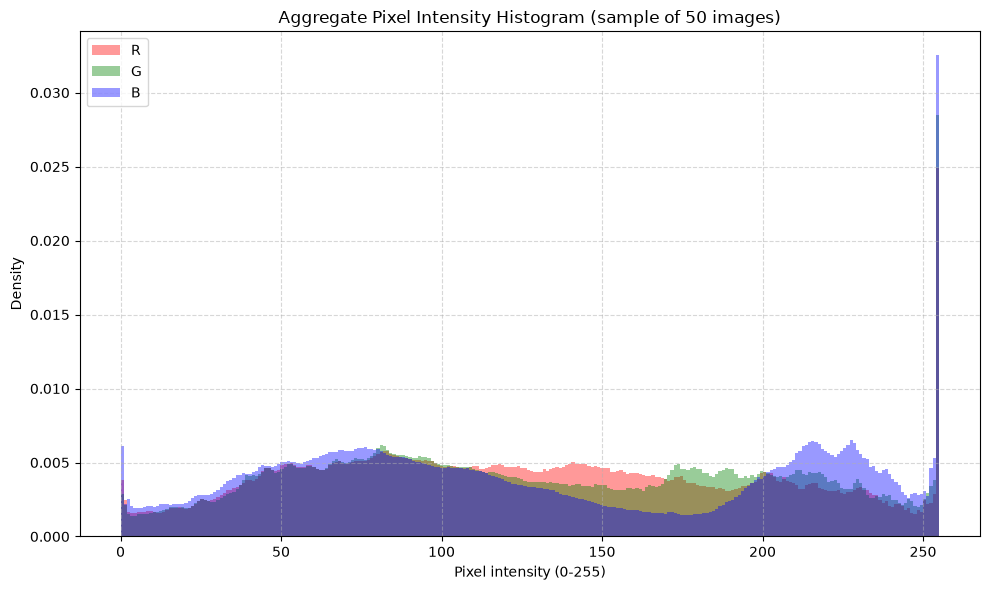

In [11]:
SAMPLE_SIZE = 50  # increase for more precision, decrease for speed

sample = image_data if len(image_data) <= SAMPLE_SIZE else list(
    np.random.choice(image_data, SAMPLE_SIZE, replace=False)
)

r_vals, g_vals, b_vals = [], [], []
for d in sample:
    try:
        with Image.open(d["path"]) as img:
            arr = np.asarray(img.convert("RGB"), dtype=np.uint8)
            r_vals.append(arr[:, :, 0].flatten())
            g_vals.append(arr[:, :, 1].flatten())
            b_vals.append(arr[:, :, 2].flatten())
    except Exception as e:
        print(f"Skipping {d['path']}: {e}")

r_vals = np.concatenate(r_vals)
g_vals = np.concatenate(g_vals)
b_vals = np.concatenate(b_vals)

plt.figure(figsize=(10, 6))
plt.hist(r_vals, bins=256, range=(0, 255), alpha=0.4, color="red", label="R", density=True)
plt.hist(g_vals, bins=256, range=(0, 255), alpha=0.4, color="green", label="G", density=True)
plt.hist(b_vals, bins=256, range=(0, 255), alpha=0.4, color="blue", label="B", density=True)
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Density")
plt.title(f"Aggregate Pixel Intensity Histogram (sample of {len(sample)} images)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Summary

In [ ]:
print("--- Summary ---")
print(f"Total images analyzed: {len(image_data)}")
if image_data:
    print(f"Brightness - min: {min(brightness):.1f}, max: {max(brightness):.1f}, avg: {np.mean(brightness):.1f}")
    print(f"Contrast   - min: {min(contrast):.1f}, max: {max(contrast):.1f}, avg: {np.mean(contrast):.1f}")


--- Summary ---
Total images analyzed: 7706
Brightness - min: 35.1, max: 188.7, avg: 132.2
Contrast   - min: 25.8, max: 106.3, avg: 64.1
